In [13]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Set visual theme
sns.set_theme(style="whitegrid")

In [14]:
# ------------------------------------------------------------------------------
# Step 1: Paths & Loading Artifacts
# ------------------------------------------------------------------------------
BASE_DIR = Path("/home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction")
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "split_data.pkl"
BEST_MODEL_PATH = BASE_DIR / "models" / "best_model.pkl"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
print("--- Step 1: Loading Saved Champion Model and Artifacts ---")
best_model = joblib.load(BEST_MODEL_PATH)
data_artifacts = joblib.load(PROCESSED_DATA_PATH)

feature_names = data_artifacts["feature_names"]
X_val = data_artifacts["X_val"]
y_val = data_artifacts["y_val"]

model_type = type(best_model).__name__
print(f"Loaded Champion Model: {model_type}")


--- Step 1: Loading Saved Champion Model and Artifacts ---
Loaded Champion Model: LGBMClassifier



--- Step 2: Extracting Feature Importance Weights ---

Top 10 Most Important Features:
            Feature  Importance  Importance_pct
      policy_tenure        1061       28.714479
age_of_policyholder         782       21.163735
         age_of_car         568       15.372124
 population_density         242        6.549391
       gross_weight         115        3.112314
       displacement          74        2.002706
             height          68        1.840325
   area_cluster_C18          51        1.380244
               make          37        1.001353
    area_cluster_C7          32        0.866035

Saved feature importance table: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/feature_importances.csv

--- Step 3: Generating Feature Importance Plot ---


/tmp/ipykernel_43291/1782804400.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Saved plot to: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/feature_importance.png
Displaying Feature Importance Plot...


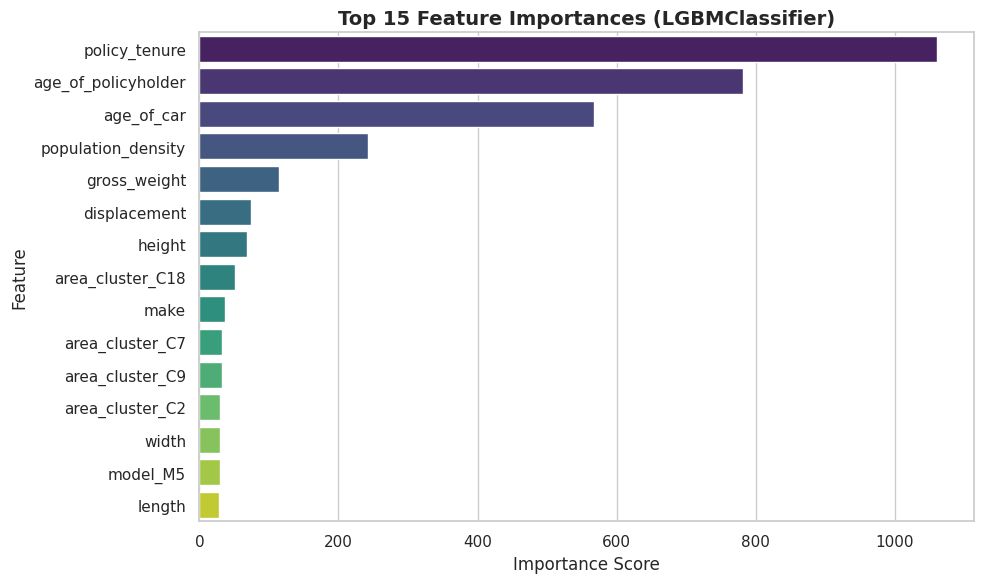

In [21]:
# ------------------------------------------------------------------------------
# Step 2: Extract Feature Importances
# ------------------------------------------------------------------------------
print("\n--- Step 2: Extracting Feature Importance Weights ---")

# Extract importance scores based on model family
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    print("Warning: Model does not have built-in feature importances/coefficients.")
    importances = None

if importances is not None:
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values(by="Importance", ascending=False)

    # Calculate percentage contribution
    importance_df["Importance_pct"] = (
        importance_df["Importance"] / importance_df["Importance"].sum()
    ) * 100

    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    # Save feature importances report to CSV
    importance_df.to_csv(REPORTS_DIR / "feature_importances.csv", index=False)
    print(f"\nSaved feature importance table: {REPORTS_DIR / 'feature_importances.csv'}")

    # --------------------------------------------------------------------------
    # Step 3: Visualize Top 15 Features
    # --------------------------------------------------------------------------
    print("\n--- Step 3: Generating Feature Importance Plot ---")
    top_15 = importance_df.head(15)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x="Importance",
        y="Feature",
        data=top_15,
        palette="viridis",
    )
    plt.title(
        f"Top 15 Feature Importances ({model_type})",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")

    plt.tight_layout()
    output_image_path = REPORTS_DIR / "feature_importance.png"
    plt.savefig(output_image_path)
    print(f"Saved plot to: {output_image_path}")

    print("Displaying Feature Importance Plot...")
    plt.show()  # Opens display pop-up window


In [22]:
# ------------------------------------------------------------------------------
# Step 3: Model Diagnostic Evaluation & Predictions
# ------------------------------------------------------------------------------
print("\n--- Step 3: Generating Model Predictions ---")
y_pred = best_model.predict(X_val)

if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_val)[:, 1]
else:
    y_proba = y_pred

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["No Claim (0)", "Claim (1)"]))


--- Step 3: Generating Model Predictions ---

Classification Report:
              precision    recall  f1-score   support

No Claim (0)       0.96      0.57      0.72     10969
   Claim (1)       0.09      0.64      0.16       750

    accuracy                           0.58     11719
   macro avg       0.53      0.61      0.44     11719
weighted avg       0.90      0.58      0.68     11719




--- Step 4: Generating Confusion Matrix Plot ---
Saved plot: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/confusion_matrix.png
Displaying Confusion Matrix Plot...


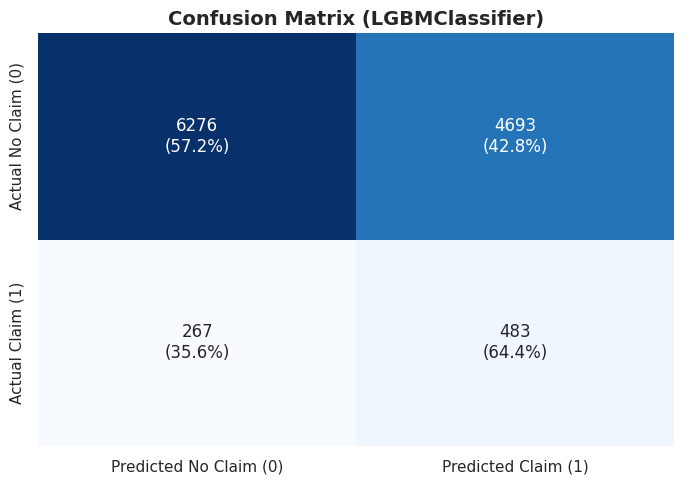

In [23]:
# ------------------------------------------------------------------------------
# Step 4: Confusion Matrix Plot
# ------------------------------------------------------------------------------
print("\n--- Step 4: Generating Confusion Matrix Plot ---")
cm = confusion_matrix(y_val, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(7, 5))
annot_labels = [
    f"{val}\n({pct:.1f}%)" for val, pct in zip(cm.flatten(), cm_percent.flatten())
]
annot_matrix = np.asarray(annot_labels).reshape(2, 2)

sns.heatmap(
    cm,
    annot=annot_matrix,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No Claim (0)", "Predicted Claim (1)"],
    yticklabels=["Actual No Claim (0)", "Actual Claim (1)"],
)
plt.title(f"Confusion Matrix ({model_type})", fontsize=14, fontweight="bold")
plt.tight_layout()

cm_path = REPORTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path)
print(f"Saved plot: {cm_path}")
print("Displaying Confusion Matrix Plot...")
plt.show()
plt.close()


--- Step 5: Generating ROC Curve Plot ---


Saved plot: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/roc_curve.png
Displaying ROC Curve Plot...


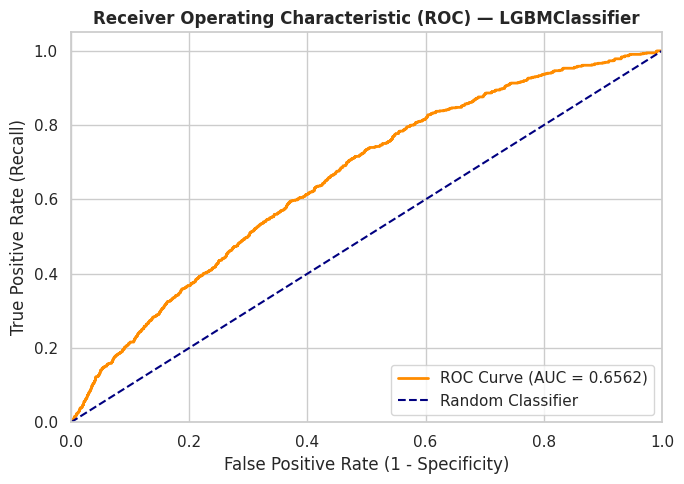

In [24]:
# ------------------------------------------------------------------------------
# Step 5: ROC Curve Plot
# ------------------------------------------------------------------------------
print("\n--- Step 5: Generating ROC Curve Plot ---")
fpr, tpr, _ = roc_curve(y_val, y_proba)
roc_auc_val = roc_auc_score(y_val, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc_val:.4f})",
)
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title(f"Receiver Operating Characteristic (ROC) — {model_type}", fontsize=12, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()

roc_path = REPORTS_DIR / "roc_curve.png"
plt.savefig(roc_path)
print(f"Saved plot: {roc_path}")
print("Displaying ROC Curve Plot...")
plt.show()
plt.close()


--- Step 6: Generating Precision-Recall Curve Plot ---
Saved plot: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/precision_recall_curve.png
Displaying Precision-Recall Curve Plot...


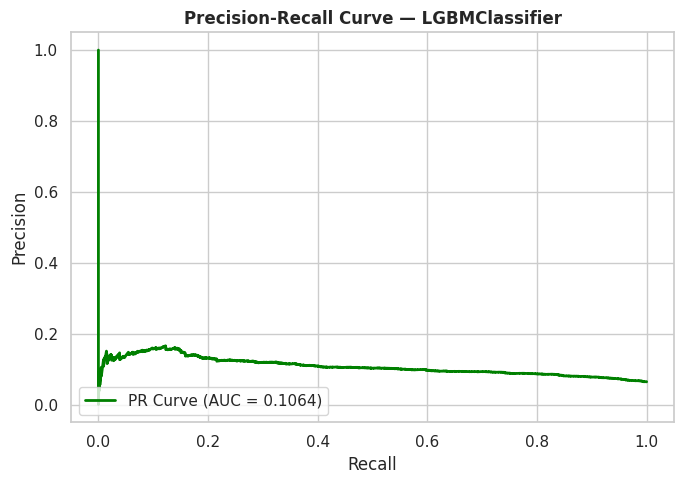


             EXPLAINABILITY & EVALUATION COMPLETED                        


In [25]:
# ------------------------------------------------------------------------------
# Step 6: Precision-Recall Curve Plot
# ------------------------------------------------------------------------------
print("\n--- Step 6: Generating Precision-Recall Curve Plot ---")
precision, recall, _ = precision_recall_curve(y_val, y_proba)
pr_auc_val = auc(recall, precision)

plt.figure(figsize=(7, 5))
plt.plot(
    recall,
    precision,
    color="green",
    lw=2,
    label=f"PR Curve (AUC = {pr_auc_val:.4f})",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {model_type}", fontsize=12, fontweight="bold")
plt.legend(loc="lower left")
plt.tight_layout()

pr_path = REPORTS_DIR / "precision_recall_curve.png"
plt.savefig(pr_path)
print(f"Saved plot: {pr_path}")
print("Displaying Precision-Recall Curve Plot...")
plt.show()
plt.close()

print("\n==========================================================================")
print("             EXPLAINABILITY & EVALUATION COMPLETED                        ")
print("==========================================================================")